In [1]:
import os
import cantera as ct
import numpy as np
import pandas as pd
import ess
import glob
import sys

import yaml
import logging

import arviz
import zeus

import sys
sys.path.append('/projects/westgroup/harris.se/uncertainty_estimator/bpe/simulation/')
import simulation

import matplotlib.pyplot as plt
%matplotlib inline

DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend inline version unknown.


In [2]:
logging.basicConfig()
logging.getLogger().setLevel(logging.INFO)

In [14]:
working_dir = '/scratch/harris.se/guassian_scratch/mk3_runs/multi_20260210/'
correlated = True
if correlated:
    label = 'corr'
else:
    label = 'uncorr'
example_run_dir = os.path.join(working_dir, f'cpox_{label}', f'cpox_{label}_0000')

In [15]:
sim_info_yaml = os.path.join(example_run_dir, 'sim_info.yaml')
with open(sim_info_yaml) as f:
    sim_info = yaml.safe_load(f)

In [16]:
chain_0s = sorted(glob.glob(os.path.join(working_dir, f'cpox_{label}', '*', 'results', 'chain_0.npy')))
chain_1s = sorted(glob.glob(os.path.join(working_dir, f'cpox_{label}', '*', 'results', 'chain_1.npy')))

logp_0s = sorted(glob.glob(os.path.join(working_dir, f'cpox_{label}', '*', 'results', 'logPs_0.npy')))
logp_1s = sorted(glob.glob(os.path.join(working_dir, f'cpox_{label}', '*', 'results', 'logPs_1.npy')))

In [17]:
# concatenate all chains and logPs

N_burn_in = 50


chain0 = np.load(chain_0s[0])[N_burn_in:, :, :]
logP0 = np.load(logp_0s[0])[N_burn_in:]


chain1 = np.load(chain_1s[0])[N_burn_in:, :, :]
logP1 = np.load(logp_1s[0])[N_burn_in:]

chain = np.concatenate((chain0, chain1))
logP = np.concatenate((logP0, logP1))

for i in range(1, len(chain_0s)):
    chain0 = np.load(chain_0s[i])[N_burn_in:, :, :]
    logP0 = np.load(logp_0s[i])[N_burn_in:]
    
    chain1 = np.load(chain_1s[i])[N_burn_in:, :, :]
    logP1 = np.load(logp_1s[i])[N_burn_in:]
    
    chain = np.concatenate((chain, chain0))
    chain = np.concatenate((chain, chain1))
    logP = np.concatenate((logP, logP0))
    logP = np.concatenate((logP, logP1))

assert chain.shape[0] == logP.shape[0]

In [18]:
chain.shape

(28526, 22, 11)

In [19]:
logP = ess.flatten_logP(logP)
chain = ess.flatten_chain(chain)

In [20]:
MAP_index = np.argmax(logP)
MAP_params = chain[MAP_index, :]

In [21]:
mech_yaml = os.path.join(example_run_dir, 'chem_annotated.yaml')
gas = ct.Solution(mech_yaml)
surf = ct.Interface(mech_yaml, "surface1", [gas])


In [22]:
thermo_perturb = {}
for i, param in enumerate(MAP_params[:len(sim_info['prior_species_indices'])]):
    thermo_perturb[sim_info['prior_species_indices'][i]] = param  # expecting units of J/mol

kinetics_perturb = {}
for i, param in enumerate(MAP_params[len(sim_info['prior_species_indices']):]):
    kinetics_perturb[sim_info['prior_reaction_indices'][i]] = np.float_power(10.0, param)  # expecting units of multiplier

gas_out, surf_out, gas_rates, surf_rates = simulation.run_simulation(
    mech_yaml,
    surf_thermo_perturb=thermo_perturb,
    surf_kinetics_perturb=kinetics_perturb,
)

Text(0.5, 1.0, 'Base case')

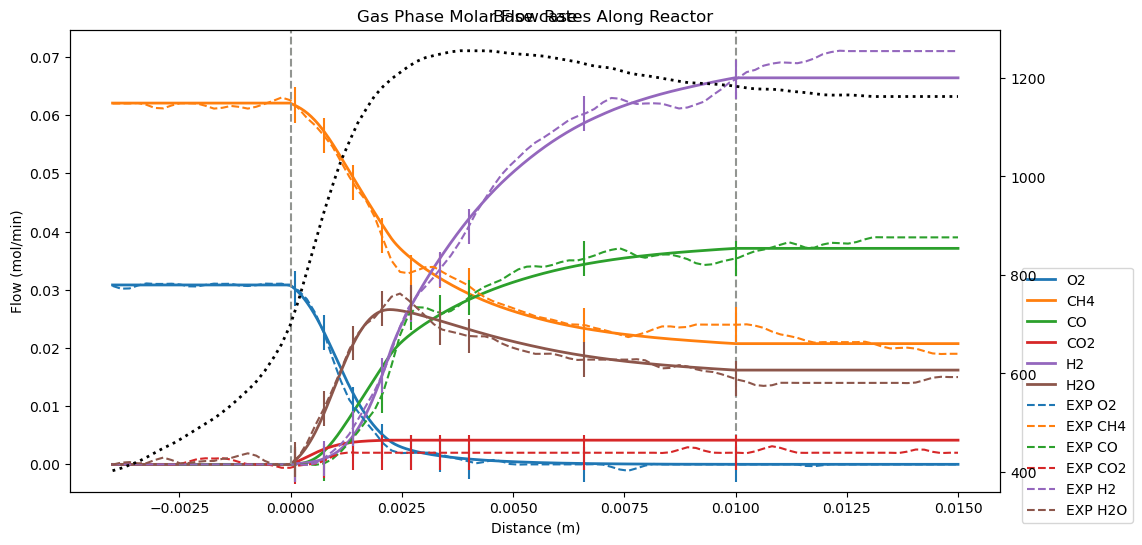

In [23]:
fig, ax = simulation.plot_gas_results(gas_out, gas)
# simulation.plot_gas_results(gas_out, gas)
experiment_csv = os.path.join(example_run_dir, 'experiment.csv')
experiment_uncertainty_csv = os.path.join(example_run_dir, 'experiment_uncertainty.csv')

experiment_df = pd.read_csv(experiment_csv)
experiment_uncertainty_df = pd.read_csv(experiment_uncertainty_csv)

# # ------------------------ Plot the experiment to show which points we picked ---------------#
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
species_headers = ['O2 (mol/min)', 'CH4 (mol/min)', 'CO (mol/min)',
       'CO2 (mol/min)', 'H2 (mol/min)', 'H2O (mol/min)']


for i in range(len(species_headers)):
    ax.errorbar(
        sim_info['sample_distances'],
        experiment_df[species_headers[i]].values,
        yerr=experiment_uncertainty_df[species_headers[i]].values,
        color=colors[i],
        label='_no_label',
        fmt='none'
    )
plt.title('Base case')



In [ ]:
ct.yamlwriter

In [28]:
mech_yaml

'/scratch/harris.se/guassian_scratch/mk3_runs/multi_20260210/cpox_uncorr/cpox_uncorr_0000/chem_annotated.yaml'

In [40]:
len(content['species'])

50

In [19]:
thermo_perturb

{1: np.float64(-75606.10267624544),
 2: np.float64(55.47528893370031),
 3: np.float64(72334.00792229695),
 4: np.float64(220.23571187234901),
 5: np.float64(-14838.455462506347),
 6: np.float64(-32887.175896799075),
 7: np.float64(10319.04605711122),
 8: np.float64(-20311.774551024133),
 9: np.float64(4067.34498068747),
 10: np.float64(-69078.54842812248),
 11: np.float64(33533.968267501805)}

In [25]:
content['species'][gas.n_species + 1]

# for i in range(len(data_copy['thermo']['data'])):
#         data_copy['thermo']['data'][i][5] += increase_enthalpy_J_per_mol * 1000.0 / ct.gas_constant  # Cantera needs J / kmol

{'composition': {'H': 1, 'X': 1},
 'name': 'HX(21)',
 'thermo': {'data': [[-2.07570125,
    0.0173580835,
    -2.60920784e-05,
    1.89282268e-08,
    -5.38835643e-12,
    np.float64(-12259.51361447419),
    8.15361518],
   [2.72248139,
    -0.00106817206,
    1.9865379e-06,
    -1.12048461e-09,
    2.09811636e-13,
    np.float64(-13311.562984474189),
    -15.320747]],
  'model': 'NASA7',
  'note': 'Thermo library: surfaceThermoPt111',
  'temperature-ranges': [298.0, 1000.0, 2000.0]}}

In [24]:
with open(mech_yaml, 'r') as f:
    content = yaml.load(f, Loader=yaml.FullLoader)


for index in thermo_perturb.keys():
    increase_enthalpy_J_per_mol = thermo_perturb[index]
    logging.debug(f"Increased enthalpy of surface species {surf.species_names[index]} by {thermo_perturb[index]} J/mol")
    for i in range(len(content['species'][gas.n_species + index]['thermo']['data'])):
        content['species'][gas.n_species + index]['thermo']['data'][i][5] += float(increase_enthalpy_J_per_mol) * 1000.0 / ct.gas_constant  # Cantera needs J / kmol

MAP_yaml_file = os.path.join(example_run_dir, f'MAP_mech.yaml')
with open(MAP_yaml_file, 'w') as outfile:
    yaml.dump(content, outfile, default_flow_style=False)



In [25]:
MAP_yaml_file

'/scratch/harris.se/guassian_scratch/mk3_runs/multi_20260210/cpox_corr/cpox_corr_0000/MAP_mech.yaml'

In [31]:
surf_thermo_perturb

NameError: name 'surf_thermo_perturb' is not defined

In [33]:
thermo_perturb

{1: np.float64(-75606.10267624544),
 2: np.float64(55.47528893370031),
 3: np.float64(72334.00792229695),
 4: np.float64(220.23571187234901),
 5: np.float64(-14838.455462506347),
 6: np.float64(-32887.175896799075),
 7: np.float64(10319.04605711122),
 8: np.float64(-20311.774551024133),
 9: np.float64(4067.34498068747),
 10: np.float64(-69078.54842812248),
 11: np.float64(33533.968267501805)}